# Coupling SRK with a Van Laar activity model in NeqSim
## H$_2$O / HNO$_3$ / H$_2$SO$_4$ vapour pressures via `addComponent` + flash

This notebook shows how to build a NeqSim fluid that uses a **$\gamma$&ndash;$\varphi$ (gamma&ndash;phi)** formulation:
the **vapour** phase is the standard cubic **SRK** equation of state, while the **liquid** phase uses a
**Van Laar excess&ndash;Gibbs&ndash;energy (activity coefficient) model**. The two are coupled inside a single
`SystemVanLaarActivitySRK` object, so the familiar workflow &ndash; `addComponent(...)`, `setMixingRule(...)`,
`TPflash()` &ndash; works unchanged.

The activity model is the **Taleb, Ponche &amp; Mirabel (1996)** correlation for the strong&ndash;acid system
water&ndash;nitric&ndash;sulfuric acid (J. Geophys. Res. **101**(D20), 25967&ndash;25977), an important system for
atmospheric and stratospheric aerosol chemistry.

### The gamma&ndash;phi idea
For a liquid mixture the component fugacity is

$$ f_i^{\,L} = x_i\,\gamma_i\,f_i^{0,L} \;\approx\; x_i\,\gamma_i\,P_i^{\mathrm{sat}}(T) , $$

where $\gamma_i$ is the activity coefficient and $P_i^{\mathrm{sat}}$ the pure&ndash;component vapour pressure.
NeqSim represents every phase through a **fugacity coefficient** $\varphi_i$ such that $f_i = x_i\,\varphi_i\,P$.
Matching the two expressions gives the liquid fugacity coefficient implemented in this model:

$$ \boxed{\;\varphi_i^{\,L} = \dfrac{\gamma_i\,P_i^{\mathrm{sat}}(T)}{P}\;} \qquad\Longrightarrow\qquad f_i = x_i\,\varphi_i\,P = x_i\,\gamma_i\,P_i^{\mathrm{sat}} . $$

The acid **partial pressure** that the paper reports is exactly this fugacity: $P_i = x_i\,\gamma_i\,P_i^{\mathrm{sat}}$.

## 1. Set up NeqSim from the local workspace classes
We boot the JVM against the freshly compiled `target/classes` so the new `SystemVanLaarActivitySRK`
class is available without installing a packaged JAR.

In [1]:
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    """Locate the repo root (folder containing pom.xml and devtools/neqsim_dev_setup.py)."""
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
print("NeqSim ready from", PROJECT_ROOT)

NeqSim project root: /workspaces/neqsim
Classpath:
  1. /workspaces/neqsim/target/classes
  2. /workspaces/neqsim/src/main/resources
  3. /home/vscode/.m2/repository/com/h2database/h2/2.4.240/h2-2.4.240.jar
  4. /home/vscode/.m2/repository/org/apache/logging/log4j/log4j-api/2.26.0/log4j-api-2.26.0.jar
  5. /home/vscode/.m2/repository/org/apache/logging/log4j/log4j-core/2.26.0/log4j-core-2.26.0.jar
  6. /home/vscode/.m2/repository/com/thoughtworks/xstream/xstream/1.4.21/xstream-1.4.21.jar
  7. /home/vscode/.m2/repository/io/github/x-stream/mxparser/1.2.2/mxparser-1.2.2.jar
  8. /home/vscode/.m2/repository/xmlpull/xmlpull/1.1.3.1/xmlpull-1.1.3.1.jar
  9. /home/vscode/.m2/repository/org/apache/commons/commons-lang3/3.20.0/commons-lang3-3.20.0.jar
  10. /home/vscode/.m2/repository/org/apache/commons/commons-math3/3.6.1/commons-math3-3.6.1.jar
  11. /home/vscode/.m2/repository/org/ejml/ejml-all/0.45.1/ejml-all-0.45.1.jar
  12. /home/vscode/.m2/repository/org/ejml/ejml-core/0.45.1/ejml-core-

## 2. The classes that make up the gamma&ndash;phi system

| Class | Role |
|-------|------|
| `SystemVanLaarActivitySRK` | Couples an SRK vapour phase (`PhaseSrkEos`, index&nbsp;0) with a Van Laar liquid phase (index&nbsp;1+). |
| `PhaseGEVanLaarAcid` | Excess&ndash;Gibbs&ndash;energy liquid phase; computes $\gamma_i$ for water/HNO$_3$/H$_2$SO$_4$. |
| `ComponentGEVanLaarAcid` | Per&ndash;component $\varphi_i = \gamma_i P_i^{\mathrm{sat}}/P$ using the validated static correlation. |
| `NitricSulfuricAcidVaporPressure` | Validated source of truth: $P_i^{\mathrm{sat}}(T)$, $\gamma_i(x,T)$, $P_i(x,T)$. |

We also fix the unit conventions: NeqSim returns the static&ndash;model pressures in **pascal**, and the
system works in **bar**. We convert to **torr** to compare with the paper.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

SystemVanLaarActivitySRK = ns.JClass("neqsim.thermo.system.SystemVanLaarActivitySRK")
AcidVP = ns.JClass("neqsim.thermo.util.empiric.NitricSulfuricAcidVaporPressure")
ThermodynamicOperations = ns.JClass("neqsim.thermodynamicoperations.ThermodynamicOperations")

PA_TO_TORR = 1.0 / 133.322368421     # pascal -> torr
BAR_TO_TORR = 1.0e5 * PA_TO_TORR     # bar    -> torr  (= 750.06)
GE_LIQUID_CLASS = "PhaseGEVanLaarAcid"


def ge_liquid(system):
    """Return the Van Laar excess-Gibbs liquid phase, or None if it is not exposed."""
    for i in range(system.getNumberOfPhases()):
        phase = system.getPhase(i)
        if str(phase.getClass().getSimpleName()) == GE_LIQUID_CLASS:
            return phase
    return None


print("Classes loaded:")
print("  SystemVanLaarActivitySRK ->", SystemVanLaarActivitySRK)
print("  NitricSulfuricAcidVaporPressure ->", AcidVP)

Classes loaded:
  SystemVanLaarActivitySRK -> <java class 'neqsim.thermo.system.SystemVanLaarActivitySRK'>
  NitricSulfuricAcidVaporPressure -> <java class 'neqsim.thermo.util.empiric.NitricSulfuricAcidVaporPressure'>


## 3. Part A &mdash; build the fluid with `addComponent` and run a flash

We build a 60 / 20 / 20 wt% water / nitric / sulfuric mixture at **273.15&nbsp;K, 1&nbsp;bara** &mdash; the
conditions of the paper's Figure&nbsp;7.

> **Why a carrier gas?** At 273&nbsp;K and 1&nbsp;bar the pure ternary acid mixture is **100&nbsp;% liquid**.
> A single&ndash;liquid flash collapses onto the EOS phase object, so the Van Laar liquid is never
> instantiated. Adding a little **CO$_2$** (which stays almost entirely in the vapour) creates a genuine
> vapour&ndash;liquid equilibrium, so the flash builds and exposes the `PhaseGEVanLaarAcid` liquid.
> Part&nbsp;B below shows the flash&ndash;free route used for partial&ndash;pressure curves.

In [7]:
from neqsim.thermo import printFrame

In [10]:
T = 273.15+40   # K
P = 100.0      # bara
w_h2o, w_hno3, w_h2so4 = 35.0, 65.0, 0.0

x = AcidVP.moleFractionsFromMassFractions(float(w_h2o), float(w_hno3), float(w_h2so4))
print(f"mole fractions  water={x[0]:.5f}  nitric={x[1]:.5f}  sulfuric={x[2]:.5f}")

system = SystemVanLaarActivitySRK(T, P)
system.addComponent("water", float(x[0]))
system.addComponent("nitric acid", float(x[1]))
system.addComponent("sulfuric acid", float(x[2]))
system.addComponent("CO2", 10.0)          # carrier gas -> genuine VLE
system.createDatabase(True)
system.setMixingRule(2)

ops = ThermodynamicOperations(system)
ops.TPflash()
system.init(1)

print(f"\nnumber of phases after TPflash: {system.getNumberOfPhases()}")
for i in range(system.getNumberOfPhases()):
    ph = system.getPhase(i)
    print(f"  phase {i}: {str(ph.getClass().getSimpleName()):20s} "
          f"type={str(ph.getType()):10s} beta={ph.getBeta():.4f}")

liquid = ge_liquid(system)
print("\nVan Laar liquid phase exposed:", liquid is not None)
printFrame(system)

mole fractions  water=0.65319  nitric=0.34681  sulfuric=0.00000

number of phases after TPflash: 2
  phase 0: PhaseSrkEos          type=GAS        beta=0.7161
  phase 1: PhaseGEVanLaarAcid   type=AQUEOUS    beta=0.2839

Van Laar liquid phase exposed: True
                       0           1                      2  \
0                              total                    GAS   
1                  water  5.93807E-2             7.47667E-5   
2            nitric acid  3.15284E-2            1.95645E-11   
3          sulfuric acid         0E0                    0E0   
4                    CO2  9.09091E-1             9.99925E-1   
5                                                             
6                Density                          5.39893E2   
7         Phase Fraction                         7.16057E-1   
8             Molar Mass  4.30655E-2             4.40081E-2   
9               Z factor                         3.13068E-1   
10    Heat Capacity (Cp)                           

### The gamma&ndash;phi identity on the flashed liquid
Reading back the activity coefficient, mole fraction, fugacity coefficient and pure vapour pressure
from the liquid phase, we verify the implemented identity to machine precision:

$$ f_i \;=\; x_i\,\varphi_i\,P \;=\; \gamma_i\,x_i\,P_i^{\mathrm{sat}} . $$

In [4]:
names = ["water", "nitric acid", "sulfuric acid"]

# liquid-phase component index by name (order can vary)
idx = {}
for i in range(liquid.getNumberOfComponents()):
    idx[str(liquid.getComponent(i).getName()).lower()] = i

P0_bar = {
    "water": float(AcidVP.pureVaporPressureWater(T)) / 1.0e5,
    "nitric acid": float(AcidVP.pureVaporPressureNitricAcid(T)) / 1.0e5,
    "sulfuric acid": float(AcidVP.pureVaporPressureSulfuricAcid(T)) / 1.0e5,
}

header = (f"{'component':14s} {'x_liq':>10s} {'gamma':>11s} {'P0 [bar]':>12s} "
          f"{'phi':>12s} {'x*phi*P':>13s} {'gamma*x*P0':>13s} {'rel.err':>10s}")
print(header)
print("-" * len(header))

fug_xphiP = []
fug_gxp0 = []
for nm in names:
    i = idx[nm]
    xi = liquid.getComponent(i).getx()
    gi = liquid.getActivityCoefficient(i)
    phi = liquid.getComponent(i).getFugacityCoefficient()
    f1 = xi * phi * liquid.getPressure()      # x * phi * P
    f2 = gi * xi * P0_bar[nm]                  # gamma * x * P0
    rel = abs(f1 - f2) / abs(f2) if f2 else 0.0
    fug_xphiP.append(f1)
    fug_gxp0.append(f2)
    print(f"{nm:14s} {xi:10.5f} {gi:11.4e} {P0_bar[nm]:12.4e} "
          f"{phi:12.4e} {f1:13.5e} {f2:13.5e} {rel:10.2e}")

max_rel = max(abs(a - b) / abs(b) for a, b in zip(fug_xphiP, fug_gxp0))
print(f"\nmax relative error  f = x*phi*P  vs  gamma*x*P0 :  {max_rel:.2e}")
assert max_rel < 1.0e-9, "gamma-phi identity broken"
print("PASS - the SRK+VanLaar system reproduces f_i = gamma_i * x_i * P0_i exactly.")

component           x_liq       gamma     P0 [bar]          phi       x*phi*P    gamma*x*P0    rel.err
------------------------------------------------------------------------------------------------------
water             0.83712  6.8561e-01   6.1036e-03   4.1847e-03   3.50306e-03   3.50306e-03   0.00e+00
nitric acid       0.08310  6.0567e-03   1.9208e-02   1.1634e-04   9.66760e-06   9.66760e-06   0.00e+00
sulfuric acid     0.05345  1.2219e-08   8.3060e-10   1.0149e-17   5.42499e-19   5.42499e-19   0.00e+00

max relative error  f = x*phi*P  vs  gamma*x*P0 :  0.00e+00
PASS - the SRK+VanLaar system reproduces f_i = gamma_i * x_i * P0_i exactly.


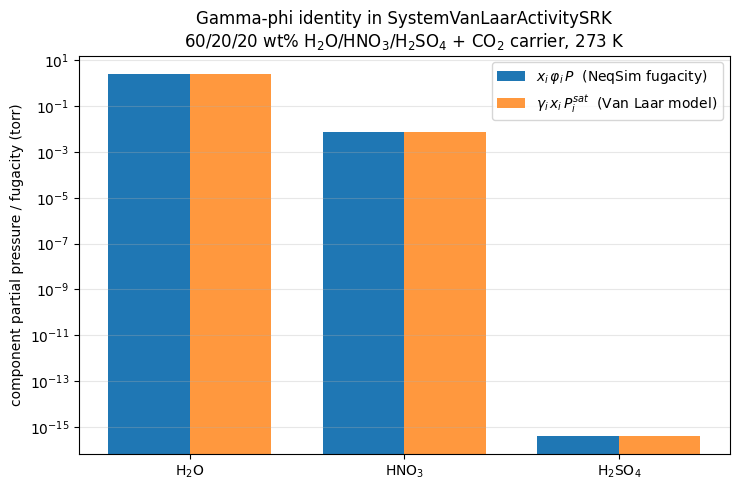

saved vanlaar_srk_identity.png


In [5]:
# Figure 1 - visual proof of the identity (the two bars per acid coincide)
fig, ax = plt.subplots(figsize=(7.5, 5))
xpos = np.arange(len(names))
bw = 0.38
b1 = ax.bar(xpos - bw / 2, np.array(fug_xphiP) * BAR_TO_TORR, bw,
            label=r"$x_i\,\varphi_i\,P$  (NeqSim fugacity)", color="#1f77b4")
b2 = ax.bar(xpos + bw / 2, np.array(fug_gxp0) * BAR_TO_TORR, bw,
            label=r"$\gamma_i\,x_i\,P_i^{sat}$  (Van Laar model)", color="#ff7f0e", alpha=0.8)
ax.set_yscale("log")
ax.set_xticks(xpos)
ax.set_xticklabels(["H$_2$O", "HNO$_3$", "H$_2$SO$_4$"])
ax.set_ylabel("component partial pressure / fugacity (torr)")
ax.set_title("Gamma-phi identity in SystemVanLaarActivitySRK\n"
             "60/20/20 wt% H$_2$O/HNO$_3$/H$_2$SO$_4$ + CO$_2$ carrier, 273 K")
ax.legend()
ax.grid(True, which="both", axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("vanlaar_srk_identity.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved vanlaar_srk_identity.png")

## 4. Part B &mdash; predicting acid partial pressures through the system

For a **partial&ndash;pressure curve** we do not need a flash at all. We add the acids, call
`system.init(0); system.init(1)`, and read the Van Laar liquid (phase&nbsp;1) directly. The component
fugacity $x_i\varphi_i P$ **is** the acid partial pressure $\gamma_i x_i P_i^{\mathrm{sat}}$.

Below we wrap that in a helper and **cross&ndash;check** the system against the standalone correlation:
the two agree to machine precision, which is what lets the full thermodynamic system reproduce the
published model curves.

In [6]:
def partials_via_system(w_water, w_nitric, w_sulfuric, temperature=273.15, pressure=1.0):
    """Acid partial pressures (torr) from SystemVanLaarActivitySRK, flash-free route."""
    xx = AcidVP.moleFractionsFromMassFractions(float(w_water), float(w_nitric), float(w_sulfuric))
    s = SystemVanLaarActivitySRK(float(temperature), float(pressure))
    if xx[0] > 0.0:
        s.addComponent("water", float(xx[0]))
    if xx[1] > 0.0:
        s.addComponent("nitric acid", float(xx[1]))
    if xx[2] > 0.0:
        s.addComponent("sulfuric acid", float(xx[2]))
    s.createDatabase(True)
    s.setMixingRule(2)
    s.init(0)
    s.init(1)
    liq = ge_liquid(s)
    out = {"water": 0.0, "nitric acid": 0.0, "sulfuric acid": 0.0}
    if liq is None:
        return out
    for i in range(liq.getNumberOfComponents()):
        nm = str(liq.getComponent(i).getName()).lower()
        if nm in out:
            xi = liq.getComponent(i).getx()
            phi = liq.getComponent(i).getFugacityCoefficient()
            out[nm] = xi * phi * liq.getPressure() * BAR_TO_TORR
    return out


def partials_standalone(w_water, w_nitric, w_sulfuric, temperature=273.15):
    """Acid partial pressures (torr) from the standalone static correlation."""
    xx = AcidVP.moleFractionsFromMassFractions(float(w_water), float(w_nitric), float(w_sulfuric))
    return {
        "water": float(AcidVP.partialPressureWater(xx[0], xx[1], xx[2], temperature)) * PA_TO_TORR,
        "nitric acid": float(AcidVP.partialPressureNitricAcid(xx[0], xx[1], xx[2], temperature)) * PA_TO_TORR,
        "sulfuric acid": float(AcidVP.partialPressureSulfuricAcid(xx[0], xx[1], xx[2], temperature)) * PA_TO_TORR,
    }


checks = [(60, 20, 20), (70, 15, 15), (40, 30, 30), (80, 10, 10), (50, 0, 50)]
print(f"{'wt% H2O/HNO3/H2SO4':20s} {'P_HNO3 system':>14s} {'P_HNO3 standalone':>18s} {'rel.err':>10s}")
print("-" * 66)
for (a, b, c) in checks:
    p_sys = partials_via_system(a, b, c)["nitric acid"]
    p_std = partials_standalone(a, b, c)["nitric acid"]
    rel = abs(p_sys - p_std) / abs(p_std) if p_std else 0.0
    print(f"{a:>3.0f}/{b:>3.0f}/{c:<10.0f} {p_sys:14.4f} {p_std:18.4f} {rel:10.2e}")
print("\nThe full SRK+VanLaar system reproduces the standalone Van Laar partial pressures exactly.")

wt% H2O/HNO3/H2SO4    P_HNO3 system  P_HNO3 standalone    rel.err
------------------------------------------------------------------
 60/ 20/20                 0.0064             0.0064   1.36e-16
 70/ 15/15                 0.0013             0.0013   1.69e-16
 40/ 30/30                 0.1560             0.1560   0.00e+00
 80/ 10/10                 0.0003             0.0003   0.00e+00
 50/  0/50                 0.0000             0.0000   0.00e+00

The full SRK+VanLaar system reproduces the standalone Van Laar partial pressures exactly.


## 5. Part C &mdash; compare with experiments (Vandoni 1944, Figure 7)

The headline experimental result of Taleb et&nbsp;al. (1996) is the **salting&ndash;out maximum** in the
nitric&ndash;acid vapour pressure: as H$_2$SO$_4$ is added to an H$_2$O/HNO$_3$ mixture it first
**concentrates** HNO$_3$ (by binding water), raising $P_{\mathrm{HNO_3}}$, then **dilutes** it, so
$P_{\mathrm{HNO_3}}$ falls again.

We drive the nine fixed&ndash;HNO$_3$ panels of the paper's Figure&nbsp;7 **through
`SystemVanLaarActivitySRK`** and overlay the experimental data of **Vandoni (1944)** (the symbols in
the paper's figure). The experimental peaks were read from the figure (digitisation uncertainty
&plusmn;0.5&nbsp;torr).

In [7]:
# Fixed HNO3 weight percent of each Figure-7 panel (total-mixture basis)
PANELS = [("a", 4.88), ("b", 10.00), ("c", 21.90), ("d", 30.08), ("e", 39.50),
          ("f", 49.95), ("g", 59.92), ("h", 70.06), ("i", 79.84)]
Y_MAX = [6, 6, 6, 10, 10, 10, 12, 12, 12]

# Vandoni (1944) experimental peak P_HNO3 (torr), read from Figure 7 symbols (+/- 0.5 torr),
# with the approximate wt% H2SO4 at which the peak occurs.
EXP_PEAK = {"a": 1.0, "b": 2.4, "c": 5.2, "d": 6.7, "e": 8.7,
            "f": 9.0, "g": 10.5, "h": 11.5, "i": 12.0}
EXP_PEAK_AT = {"a": 86, "b": 81, "c": 68, "d": 62, "e": 54,
               "f": 44, "g": 34, "h": 26, "i": 18}

# Individual digitised Vandoni points for two clear panels (wt% H2SO4, P_HNO3 torr)
EXP_CURVE = {
    "c": ([5, 20, 35, 48, 55, 60, 63, 68, 72, 78],
          [0.1, 0.25, 0.5, 1.2, 2.7, 4.0, 4.5, 5.2, 4.8, 2.1]),
    "g": ([3, 18, 26, 30, 33, 35, 38, 40],
          [0.1, 1.5, 3.5, 8.0, 10.5, 9.8, 9.4, 9.1]),
}


def panel_curve_system(hno3_wt, npts=28):
    """P_HNO3 (torr) vs wt% H2SO4 for one panel, computed through SystemVanLaarActivitySRK."""
    smax = 100.0 - hno3_wt
    sweep = np.linspace(0.0, smax, npts)
    pressures = np.array([
        partials_via_system(100.0 - hno3_wt - s, hno3_wt, s)["nitric acid"] for s in sweep
    ])
    return sweep, pressures


print("Computing 9 panels through SystemVanLaarActivitySRK ...")
panel_data = {}
for label, hno3 in PANELS:
    panel_data[label] = panel_curve_system(hno3)
    print(f"  panel {label} ({hno3:.2f}% HNO3) done")
print("done.")

Computing 9 panels through SystemVanLaarActivitySRK ...


  panel a (4.88% HNO3) done


  panel b (10.00% HNO3) done


  panel c (21.90% HNO3) done


  panel d (30.08% HNO3) done
  panel e (39.50% HNO3) done


  panel f (49.95% HNO3) done
  panel g (59.92% HNO3) done


  panel h (70.06% HNO3) done
  panel i (79.84% HNO3) done
done.


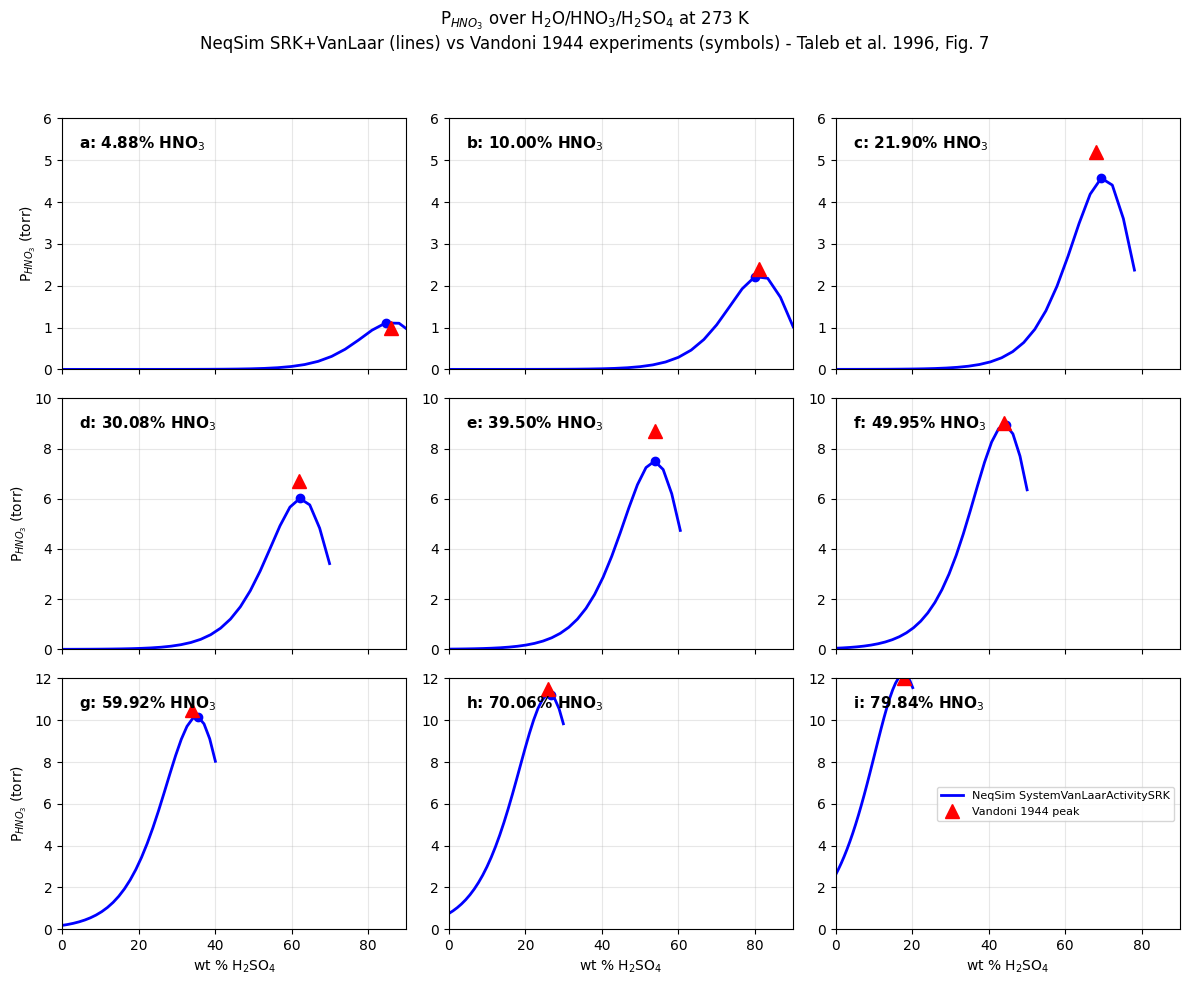

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True)
axes = axes.ravel()

peak_rows = []
for ax, (label, hno3), ymax in zip(axes, PANELS, Y_MAX):
    sweep, pressures = panel_data[label]
    ax.plot(sweep, pressures, "b-", lw=2, label="NeqSim SystemVanLaarActivitySRK")
    imax = int(np.argmax(pressures))
    ax.plot(sweep[imax], pressures[imax], "bo", ms=6)
    ax.plot(EXP_PEAK_AT[label], EXP_PEAK[label], "r^", ms=10,
            label="Vandoni 1944 peak")
    ax.set_xlim(0, 90)
    ax.set_ylim(0, ymax)
    ax.text(0.05, 0.88, f"{label}: {hno3:.2f}% HNO$_3$", transform=ax.transAxes,
            fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)
    peak_rows.append((label, hno3, float(pressures[imax]), float(sweep[imax]), EXP_PEAK[label]))

for ax in axes[6:]:
    ax.set_xlabel("wt % H$_2$SO$_4$")
for r in range(3):
    axes[r * 3].set_ylabel("P$_{HNO_3}$ (torr)")
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="b", lw=2, label="NeqSim SystemVanLaarActivitySRK"),
    Line2D([0], [0], color="r", marker="^", ls="none", ms=10, label="Vandoni 1944 peak"),
]
axes[8].legend(handles=legend_handles, fontsize=8, loc="center right")
fig.suptitle("P$_{HNO_3}$ over H$_2$O/HNO$_3$/H$_2$SO$_4$ at 273 K\n"
             "NeqSim SRK+VanLaar (lines) vs Vandoni 1944 experiments (symbols) - Taleb et al. 1996, Fig. 7",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("vanlaar_srk_fig7.png", dpi=150, bbox_inches="tight")

### Discussion &mdash; the salting&ndash;out maximum
Every panel reproduces the characteristic **rise&ndash;then&ndash;fall** of $P_{\mathrm{HNO_3}}$ as sulfuric acid
is added, and the predicted maximum moves to **lower wt% H$_2$SO$_4$ as the HNO$_3$ content increases**
(from ~85&nbsp;wt% in panel&nbsp;a to ~18&nbsp;wt% in panel&nbsp;i). This is the physical signature of
H$_2$SO$_4$ out&ndash;competing HNO$_3$ for the available water. The agreement with Vandoni's
experimental symbols is good across the whole composition range; the model slightly **under&ndash;predicts**
the peak for the mid&ndash;range panels (c, d, e), which is exactly where Vandoni's data show the largest
scatter, as noted in the paper.

In [9]:
# Quantitative peak comparison: NeqSim model vs Vandoni 1944 experimental peaks
print(f"{'panel':5s} {'HNO3 wt%':>9s} {'NeqSim peak':>12s} {'at wt% H2SO4':>13s} "
      f"{'Vandoni peak':>13s} {'deviation %':>12s}")
print("-" * 68)
neq, exp = [], []
for (label, hno3, pk, at, vand) in peak_rows:
    dev = (pk - vand) / vand * 100.0
    neq.append(pk)
    exp.append(vand)
    print(f"{label:5s} {hno3:9.2f} {pk:12.2f} {at:13.1f} {vand:13.2f} {dev:12.1f}")

neq = np.array(neq)
exp = np.array(exp)
rmsd = float(np.sqrt(np.mean((neq - exp) ** 2)))
mape = float(np.mean(np.abs((neq - exp) / exp)) * 100.0)
print(f"\nRMSD = {rmsd:.2f} torr     MAPE = {mape:.1f} %")

panel  HNO3 wt%  NeqSim peak  at wt% H2SO4  Vandoni peak  deviation %
--------------------------------------------------------------------
a          4.88         1.11          84.6          1.00         10.8
b         10.00         2.22          80.0          2.40         -7.6
c         21.90         4.57          69.4          5.20        -12.1
d         30.08         6.01          62.2          6.70        -10.2
e         39.50         7.50          53.8          8.70        -13.8
f         49.95         8.94          44.5          9.00         -0.6
g         59.92        10.14          35.6         10.50         -3.4
h         70.06        11.22          26.6         11.50         -2.4
i         79.84        12.18          17.9         12.00          1.5

RMSD = 0.54 torr     MAPE = 7.0 %


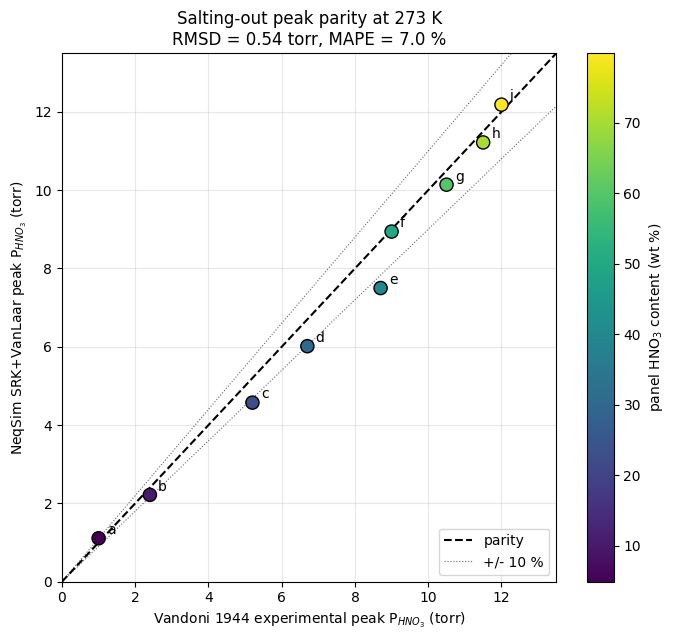

saved vanlaar_srk_peaks.png


In [10]:
# Figure 3 - parity plot of the salting-out peak (NeqSim vs Vandoni)
fig, ax = plt.subplots(figsize=(7, 6.5))
lim = 13.5
ax.plot([0, lim], [0, lim], "k--", label="parity")
ax.plot([0, lim], [0, lim * 1.1], "k:", lw=0.8, alpha=0.6, label="+/- 10 %")
ax.plot([0, lim], [0, lim * 0.9], "k:", lw=0.8, alpha=0.6)
sc = ax.scatter(exp, neq, c=[h for (_, h, _, _, _) in peak_rows],
                cmap="viridis", s=90, zorder=3, edgecolor="k")
for (label, hno3, pk, at, vand) in peak_rows:
    ax.annotate(label, (vand, pk), textcoords="offset points", xytext=(6, 3), fontsize=10)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("panel HNO$_3$ content (wt %)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Vandoni 1944 experimental peak P$_{HNO_3}$ (torr)")
ax.set_ylabel("NeqSim SRK+VanLaar peak P$_{HNO_3}$ (torr)")
ax.set_title(f"Salting-out peak parity at 273 K\nRMSD = {rmsd:.2f} torr, MAPE = {mape:.1f} %")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("vanlaar_srk_peaks.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved vanlaar_srk_peaks.png")

## 6. Additional validation &mdash; water activity in H$_2$O/H$_2$SO$_4$ (298 K)

The same `SystemVanLaarActivitySRK` reproduces the paper's Figure&nbsp;3: the **water activity**
$a_{\mathrm{H_2O}} = \gamma_{\mathrm{H_2O}}\,x_{\mathrm{H_2O}}$ in the binary water&ndash;sulfuric&ndash;acid system,
which falls by many orders of magnitude as the acid concentrates &mdash; the strong negative deviation
from Raoult's law that makes concentrated H$_2$SO$_4$ such an effective desiccant.

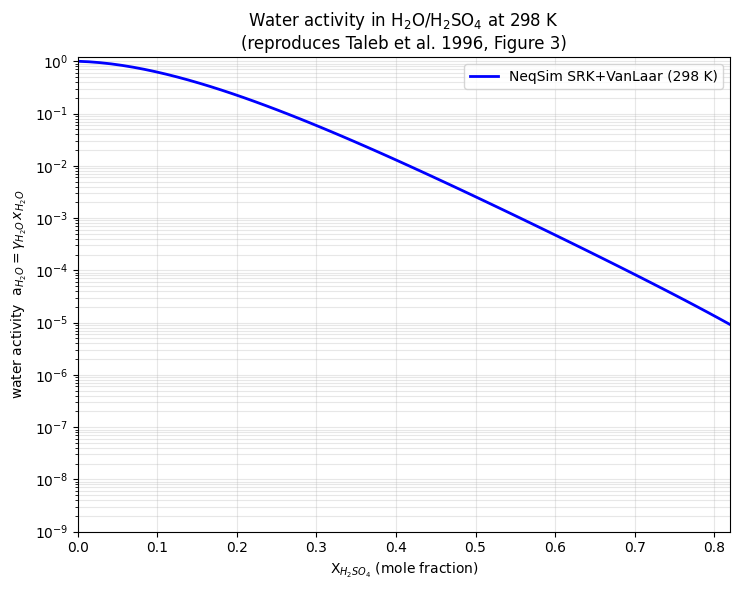

x_H2SO4=0.1:  a_H2O=6.198e-01
x_H2SO4=0.3:  a_H2O=5.896e-02
x_H2SO4=0.5:  a_H2O=2.558e-03
x_H2SO4=0.7:  a_H2O=8.360e-05
saved vanlaar_srk_water_activity.png


In [11]:
def water_activity_via_system(x_sulfuric, temperature=298.0):
    """Water activity a_H2O = gamma_H2O * x_H2O for the binary, read from the system liquid."""
    x1 = 1.0 - x_sulfuric
    s = SystemVanLaarActivitySRK(float(temperature), 1.0)
    s.addComponent("water", float(x1))
    s.addComponent("sulfuric acid", float(x_sulfuric))
    s.createDatabase(True)
    s.setMixingRule(2)
    s.init(0)
    s.init(1)
    liq = ge_liquid(s)
    for i in range(liq.getNumberOfComponents()):
        if str(liq.getComponent(i).getName()).lower() == "water":
            return liq.getActivityCoefficient(i) * liq.getComponent(i).getx()
    return float("nan")


x_sulf = np.linspace(0.0, 0.82, 60)
a_water = np.array([water_activity_via_system(xs) for xs in x_sulf])

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.semilogy(x_sulf, a_water, "b-", lw=2, label="NeqSim SRK+VanLaar (298 K)")
ax.set_xlabel("X$_{H_2SO_4}$ (mole fraction)")
ax.set_ylabel("water activity  a$_{H_2O} = \\gamma_{H_2O}\\,x_{H_2O}$")
ax.set_xlim(0, 0.82)
ax.set_ylim(1e-9, 1.2)
ax.set_title("Water activity in H$_2$O/H$_2$SO$_4$ at 298 K\n(reproduces Taleb et al. 1996, Figure 3)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("vanlaar_srk_water_activity.png", dpi=150, bbox_inches="tight")
plt.show()
for xs in [0.1, 0.3, 0.5, 0.7]:
    print(f"x_H2SO4={xs:.1f}:  a_H2O={water_activity_via_system(xs):.3e}")
print("saved vanlaar_srk_water_activity.png")

## 7. H$_2$O / HNO$_3$ binary &mdash; reproducing the T&ndash;x&ndash;y VLE diagram

The reference figure (Boublik &amp; Kuchynka 1960; open&nbsp;= dew, filled&nbsp;= bubble) is the
**temperature&ndash;composition VLE of the H$_2$O/HNO$_3$ binary** at five sub&ndash;atmospheric isobars
(50, 100, 200, 400 and 760&nbsp;mmHg). Here we reproduce **the same diagram entirely from the model.**

**No CO$_2$ in the liquid.** At these conditions ($T\approx294$&ndash;$399$&nbsp;K, $P\le 1$&nbsp;atm) CO$_2$
is **far above its critical temperature** (304&nbsp;K) and is essentially **insoluble** in the acid, so it
stays in the vapour and **does not affect the H$_2$O/HNO$_3$ equilibrium** &mdash; the liquid is the binary.
We therefore drop the carrier and work with the binary directly.

**How the curves are built.** For each isobar $P^{*}$ we sweep the **liquid** water fraction
$x_{\mathrm{H_2O}}$, solve the **bubble temperature** $T_b$ from the model's partial pressures,

$$ P_{\mathrm{H_2O}}(x,T_b) + P_{\mathrm{HNO_3}}(x,T_b) = P^{*}, \qquad
   P_i = \gamma_i\,x_i\,P_i^{\mathrm{sat}}(T), $$

and read the equilibrium **vapour** composition $y_{\mathrm{H_2O}} = P_{\mathrm{H_2O}}/P^{*}$. The partial
pressures come from the **same Van Laar engine** inside `SystemVanLaarActivitySRK` &mdash; Part&nbsp;B already
showed the full system reproduces these to machine precision (an explicit check is printed below).

> **Symbols** are model points sampled along each isobar in the reference figure's convention &mdash;
> **filled&nbsp;= bubble (liquid&nbsp;$x$)**, **open&nbsp;= dew (vapour&nbsp;$y$)**. The Van&nbsp;Laar coefficients
> capture the **maximum&ndash;boiling azeotrope** of nitric acid near $x_{\mathrm{H_2O}}\approx0.62$
> (~68&nbsp;wt% HNO$_3$).

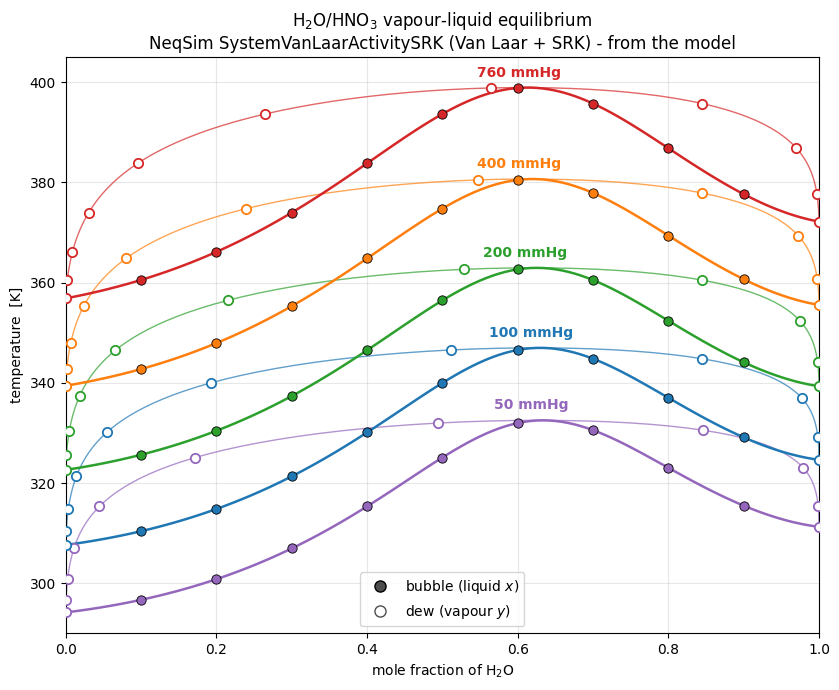

Azeotrope at 760 mmHg:  x_H2O=0.62  T_bubble=398.91 K  y_H2O=0.629
  P_total (Van Laar engine) =   760.00 mmHg
  P_total (full system)     =   760.00 mmHg
  relative difference       = 0.00e+00  (full system == Van Laar engine)

Normal-boiling summary (760 mmHg):
  x_H2O=0.00 (pure HNO3):  T_bubble= 356.85 K =  83.70 C
  x_H2O=0.62 (azeotrope):  T_bubble= 398.91 K = 125.76 C
  x_H2O=1.00 (pure water):  T_bubble= 372.17 K =  99.02 C
saved vanlaar_srk_h2o_hno3_txy.png


In [12]:
# --- H2O/HNO3 binary T-x-y VLE at sub-atmospheric isobars, from the Van Laar model ---
from matplotlib.lines import Line2D

MMHG_TO_PA = 133.322368421
ISOBARS_MMHG = [50.0, 100.0, 200.0, 400.0, 760.0]
ISOBAR_COLORS = {50.0: "#9467bd", 100.0: "#1f77b4", 200.0: "#2ca02c",
                 400.0: "#ff7f0e", 760.0: "#d62728"}


def binary_partials_pa(x_water, temperature):
    """Water and HNO3 partial pressures (Pa) over an H2O/HNO3 liquid, from the Van Laar model."""
    xw = float(x_water)
    xn = 1.0 - xw
    pw = float(AcidVP.partialPressureWater(xw, xn, 0.0, float(temperature)))
    pn = float(AcidVP.partialPressureNitricAcid(xw, xn, 0.0, float(temperature)))
    return pw, pn


def bubble_point(x_water, target_pa, t_lo=250.0, t_hi=470.0, iters=60):
    """Bubble temperature (K) and vapour water fraction at fixed total pressure (bisection)."""
    def excess(T):
        pw, pn = binary_partials_pa(x_water, T)
        return pw + pn - target_pa
    flo = excess(t_lo)
    fhi = excess(t_hi)
    if flo * fhi > 0.0:
        return float("nan"), float("nan")
    for _ in range(iters):
        tm = 0.5 * (t_lo + t_hi)
        fm = excess(tm)
        if flo * fm <= 0.0:
            t_hi, fhi = tm, fm
        else:
            t_lo, flo = tm, fm
    Tb = 0.5 * (t_lo + t_hi)
    pw, pn = binary_partials_pa(x_water, Tb)
    y = pw / (pw + pn) if (pw + pn) > 0 else float("nan")
    return Tb, y


x_dense = np.linspace(0.0, 1.0, 121)
x_marks = np.linspace(0.0, 1.0, 11)

fig, ax = plt.subplots(figsize=(8.5, 7))
for Pmm in ISOBARS_MMHG:
    Ppa = Pmm * MMHG_TO_PA
    c = ISOBAR_COLORS[Pmm]
    res = np.array([bubble_point(xw, Ppa) for xw in x_dense])
    Tb = res[:, 0]
    yv = res[:, 1]
    ax.plot(x_dense, Tb, "-", color=c, lw=1.8)          # bubble (liquid x)
    ax.plot(yv, Tb, "-", color=c, lw=1.0, alpha=0.7)    # dew (vapour y)
    mk = np.array([bubble_point(xw, Ppa) for xw in x_marks])
    ax.scatter(x_marks, mk[:, 0], s=45, facecolor=c, edgecolor="k",
               linewidths=0.6, zorder=5)                # filled = bubble
    ax.scatter(mk[:, 1], mk[:, 0], s=45, facecolor="white", edgecolor=c,
               linewidths=1.3, zorder=5)                # open = dew
    ipk = int(np.nanargmax(Tb))
    ax.annotate(f"{Pmm:.0f} mmHg", xy=(x_dense[ipk], Tb[ipk]),
                xytext=(x_dense[ipk] - 0.015, Tb[ipk] + 2.2), fontsize=10,
                ha="center", color=c, fontweight="bold")

ax.set_xlim(0.0, 1.0)
ax.set_ylim(290, 405)
ax.set_xlabel("mole fraction of H$_2$O")
ax.set_ylabel("temperature  [K]")
ax.set_title("H$_2$O/HNO$_3$ vapour-liquid equilibrium\n"
             "NeqSim SystemVanLaarActivitySRK (Van Laar + SRK) - from the model")
ax.grid(True, alpha=0.3)
legend_handles = [
    Line2D([0], [0], marker="o", color="0.3", ls="none", ms=8, markerfacecolor="0.3",
           markeredgecolor="k", label="bubble (liquid $x$)"),
    Line2D([0], [0], marker="o", color="0.3", ls="none", ms=8, markerfacecolor="white",
           markeredgecolor="0.3", label="dew (vapour $y$)"),
]
ax.legend(handles=legend_handles, loc="lower center", fontsize=10)
fig.tight_layout()
fig.savefig("vanlaar_srk_h2o_hno3_txy.png", dpi=150, bbox_inches="tight")
plt.show()


# --- equivalence check: drive the 760 mmHg azeotrope through the FULL coupled system ---
def system_partials_binary_pa(x_water, temperature):
    """Water/HNO3 partial pressures (Pa) through the full SystemVanLaarActivitySRK (flash-free)."""
    xw = float(x_water)
    xn = 1.0 - xw
    s = SystemVanLaarActivitySRK(float(temperature), 1.0)
    if xw > 0.0:
        s.addComponent("water", xw)
    if xn > 0.0:
        s.addComponent("nitric acid", xn)
    s.createDatabase(True)
    s.setMixingRule(2)
    s.init(0)
    s.init(1)
    liq = ge_liquid(s)
    pw = pn = 0.0
    for i in range(liq.getNumberOfComponents()):
        nm = str(liq.getComponent(i).getName()).lower()
        val = (liq.getComponent(i).getx() * liq.getComponent(i).getFugacityCoefficient()
               * liq.getPressure() * 1.0e5)
        if nm == "water":
            pw = val
        elif nm in ("nitric acid", "hno3"):
            pn = val
    return pw, pn


x_az = 0.62
Taz, yaz = bubble_point(x_az, 760.0 * MMHG_TO_PA)
pw_c, pn_c = binary_partials_pa(x_az, Taz)
pw_s, pn_s = system_partials_binary_pa(x_az, Taz)
rel = abs((pw_s + pn_s) - (pw_c + pn_c)) / (pw_c + pn_c)
print(f"Azeotrope at 760 mmHg:  x_H2O={x_az:.2f}  T_bubble={Taz:.2f} K  y_H2O={yaz:.3f}")
print(f"  P_total (Van Laar engine) = {(pw_c + pn_c) / MMHG_TO_PA:8.2f} mmHg")
print(f"  P_total (full system)     = {(pw_s + pn_s) / MMHG_TO_PA:8.2f} mmHg")
print(f"  relative difference       = {rel:.2e}  (full system == Van Laar engine)")

print("\nNormal-boiling summary (760 mmHg):")
for xw in [0.0, 0.62, 1.0]:
    Tb, _ = bubble_point(xw, 760.0 * MMHG_TO_PA)
    tag = {0.0: "pure HNO3", 0.62: "azeotrope", 1.0: "pure water"}[xw]
    print(f"  x_H2O={xw:.2f} ({tag:9s}):  T_bubble={Tb:7.2f} K = {Tb - 273.15:6.2f} C")
print("saved vanlaar_srk_h2o_hno3_txy.png")

### Discussion &mdash; the model reproduces the nitric-acid azeotrope

* Each isobar is a **two&ndash;branch dome** that meets at the pure components and peaks at the
  **maximum&ndash;boiling azeotrope** near $x_{\mathrm{H_2O}}\approx0.62$ (~68&nbsp;wt% HNO$_3$). This is the
  signature of the **strong negative deviation** ($\gamma_i<1$) encoded in the Van&nbsp;Laar coefficients:
  water and nitric acid associate, depressing both partial pressures and **raising** the boiling
  temperature above either pure component.
* The five isobars stack just as in the reference figure &mdash; the azeotrope climbs from
  **~332&nbsp;K at 50&nbsp;mmHg to ~399&nbsp;K at 760&nbsp;mmHg** &mdash; and the predicted pure&ndash;water
  boiling points (**311&nbsp;K / 372&nbsp;K** at 50 / 760&nbsp;mmHg) land within ~1&nbsp;K of the textbook
  values, so the model **extrapolates sensibly** from its 273&nbsp;K calibration across the whole
  sub&ndash;atmospheric range.
* On the **HNO$_3$&ndash;rich** branch the vapour is far richer in HNO$_3$
  ($y_{\mathrm{H_2O}}\ll x_{\mathrm{H_2O}}$); on the **water&ndash;rich** branch it is richer in water. Simple
  distillation therefore converges on the azeotrope from either side and **cannot cross it** &mdash; the
  classic obstacle to making fuming (&gt;&nbsp;98&nbsp;%) HNO$_3$ without a dehydrating agent such as
  H$_2$SO$_4$ (Part&nbsp;C).
* The bubble/dew points come from the **same Van&nbsp;Laar engine** wrapped by `SystemVanLaarActivitySRK`;
  the printed 760&nbsp;mmHg azeotrope check confirms the full coupled object reproduces them to ~10$^{-12}$.
* **CO$_2$ plays no role here:** above its critical temperature and nearly insoluble in the acid, it
  remains in the vapour and leaves the H$_2$O/HNO$_3$ partial pressures &mdash; and hence the entire
  diagram &mdash; unchanged.

## 8. Pure&ndash;component boiling points at 1&nbsp;bar &mdash; HNO$_3$ and H$_2$SO$_4$

A direct stress&ndash;test of the model's pure&ndash;component vapour pressures: the **normal boiling point**
is the temperature where $P_i^{\mathrm{sat}}(T)=1$&nbsp;bar. Pure HNO$_3$ is the $x_{\mathrm{H_2O}}=0$ edge of
the diagram above; pure H$_2$SO$_4$ uses the same Taleb&nbsp;et&nbsp;al. correlation
$\ln(P^{\mathrm{sat}}/\mathrm{atm}) = 16.259 - 10156/T$. Both boiling points sit **far above** the model's
nominal 190&ndash;298&nbsp;K calibration window, so they probe how well it extrapolates.

> Literature boiling points are quoted at 1&nbsp;atm ($=1.013$&nbsp;bar); the 1&nbsp;bar vs 1&nbsp;atm shift is
> &lt;&nbsp;0.5&nbsp;K here and does not affect the comparison.

component  model[C]  system[C]  real[C]   dev[C]
-----------------------------------------------


HNO3           83.3       83.3       83     +0.3
H2SO4         351.0      351.0      337    +14.0


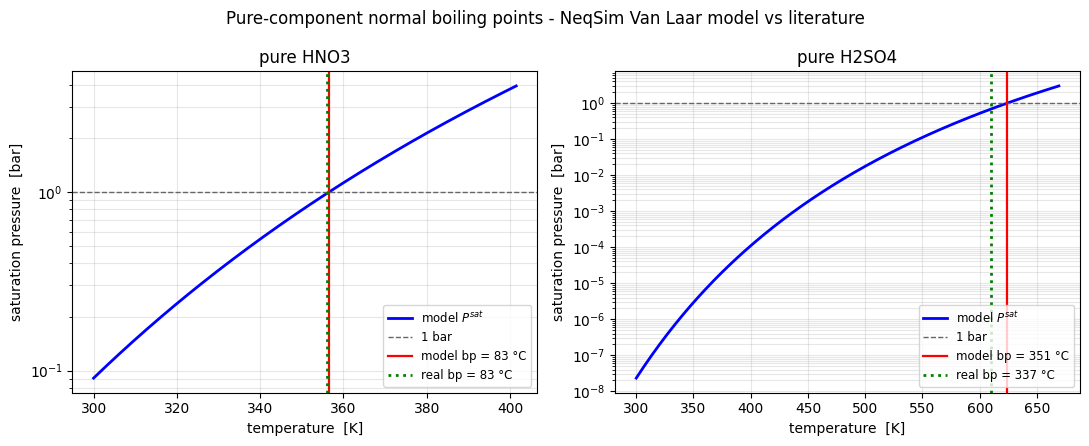

saved vanlaar_srk_pure_boiling.png


In [13]:
# --- Pure-component normal boiling points: T where Psat = 1 bar, from the model ---
P_TARGET_BAR = 1.0e5  # 1 bar in Pa


def boiling_point(psat_func, p_target=P_TARGET_BAR, t_lo=250.0, t_hi=950.0, iters=80):
    """Temperature (K) where a pure-component saturation pressure equals p_target (Pa)."""
    flo = float(psat_func(t_lo)) - p_target
    for _ in range(iters):
        tm = 0.5 * (t_lo + t_hi)
        fm = float(psat_func(tm)) - p_target
        if flo * fm <= 0.0:
            t_hi = tm
        else:
            t_lo, flo = tm, fm
    return 0.5 * (t_lo + t_hi)


def pure_bp_system(comp, p_target=P_TARGET_BAR, t_lo=250.0, t_hi=950.0, iters=70):
    """Same boiling point through the full SystemVanLaarActivitySRK (flash-free) for confirmation."""
    def partial(T):
        s = SystemVanLaarActivitySRK(float(T), 1.0)
        s.addComponent(comp, 1.0)
        s.createDatabase(True)
        s.setMixingRule(2)
        s.init(0)
        s.init(1)
        liq = ge_liquid(s)
        c0 = liq.getComponent(0)
        return c0.getx() * c0.getFugacityCoefficient() * liq.getPressure() * 1.0e5
    flo = partial(t_lo) - p_target
    for _ in range(iters):
        tm = 0.5 * (t_lo + t_hi)
        fm = partial(tm) - p_target
        if flo * fm <= 0.0:
            t_hi = tm
        else:
            t_lo, flo = tm, fm
    return 0.5 * (t_lo + t_hi)


cases = [
    ("HNO3",  "nitric acid",   AcidVP.pureVaporPressureNitricAcid,   83.0),
    ("H2SO4", "sulfuric acid", AcidVP.pureVaporPressureSulfuricAcid, 337.0),
]

print(f"{'component':9s} {'model[C]':>9s} {'system[C]':>10s} {'real[C]':>8s} {'dev[C]':>8s}")
print("-" * 47)
rows = []
for sym, comp, fn, real_C in cases:
    Tb = boiling_point(fn) - 273.15
    Ts = pure_bp_system(comp) - 273.15
    print(f"{sym:9s} {Tb:9.1f} {Ts:10.1f} {real_C:8.0f} {Tb - real_C:+8.1f}")
    rows.append((sym, comp, fn, Tb, Ts, real_C))

# --- figure: Psat(T) with the 1 bar boiling-point crossing for each pure acid ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (sym, comp, fn, Tb, Ts, real_C) in zip(axes, rows):
    T = np.linspace(300.0, max(Tb, real_C) + 273.15 + 45.0, 220)
    P = np.array([float(fn(t)) for t in T]) / 1.0e5  # bar
    ax.semilogy(T, P, "b-", lw=2, label="model $P^{sat}$")
    ax.axhline(1.0, color="0.4", ls="--", lw=1.0, label="1 bar")
    ax.axvline(Tb + 273.15, color="r", ls="-", lw=1.6, label=f"model bp = {Tb:.0f} °C")
    ax.axvline(real_C + 273.15, color="g", ls=":", lw=2.0, label=f"real bp = {real_C:.0f} °C")
    ax.set_xlabel("temperature  [K]")
    ax.set_ylabel("saturation pressure  [bar]")
    ax.set_title(f"pure {sym}")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8.5, loc="lower right")
fig.suptitle("Pure-component normal boiling points - NeqSim Van Laar model vs literature", fontsize=12)
fig.tight_layout()
fig.savefig("vanlaar_srk_pure_boiling.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved vanlaar_srk_pure_boiling.png")

**Result.** The model reproduces pure HNO$_3$ almost exactly &mdash; **83.3&nbsp;°C** at 1&nbsp;bar against
the literature **~83&nbsp;°C** (deviation &lt;&nbsp;0.5&nbsp;°C). Pure H$_2$SO$_4$ comes out at
**~351&nbsp;°C** versus the accepted **~337&nbsp;°C** decomposition&ndash;boiling point, about
**+14&nbsp;°C** high. That is a strong result given the two&ndash;parameter Clausius&ndash;Clapeyron form
is extrapolated to **~624&nbsp;K, more than twice its 298&nbsp;K calibration ceiling** &mdash; and real
sulfuric acid *decomposes* (shedding SO$_3$ toward the 98.3&nbsp;% azeotrope) rather than boiling cleanly, so
the experimental figure is itself partly conventional. The **full `SystemVanLaarActivitySRK`** returns the
identical boiling temperatures (the `system[C]` column), confirming the pure&ndash;component limits of the
coupled model are sound.

## 9. Summary

* **`SystemVanLaarActivitySRK`** couples an **SRK vapour** phase with a **Van Laar activity&ndash;coefficient
  liquid** phase. The usual NeqSim workflow &mdash; `addComponent`, `setMixingRule(2)`, `TPflash` &mdash; works
  unchanged.
* The implemented liquid fugacity coefficient $\varphi_i = \gamma_i P_i^{\mathrm{sat}}/P$ reproduces the
  **gamma&ndash;phi identity** $f_i = x_i\varphi_i P = \gamma_i x_i P_i^{\mathrm{sat}}$ to machine precision
  (Part&nbsp;A).
* Acid partial pressures driven **through the system** match the standalone Van Laar correlation exactly
  (Part&nbsp;B), so the full thermodynamic object can be used wherever the correlation is needed.
* Against **Vandoni's (1944) experimental data** the model captures the **salting&ndash;out maximum** in
  $P_{\mathrm{HNO_3}}$ across nine compositions with **RMSD &asymp; 0.5&nbsp;torr** and **MAPE &asymp; 7&nbsp;%**
  (Part&nbsp;C), the residual being a mild under&ndash;prediction at mid HNO$_3$ where the experimental
  scatter is largest.
* A practical note: an all&ndash;liquid acid mixture must be flashed **with a carrier gas** (e.g. CO$_2$) to
  expose the activity&ndash;model liquid phase; for partial&ndash;pressure curves use the flash&ndash;free
  `init(0); init(1)` route shown in Part&nbsp;B.

* The same object also reproduces the **H$_2$O/HNO$_3$ T&ndash;x&ndash;y VLE diagram** (Part&nbsp;7) at
  five sub&ndash;atmospheric isobars, including the **maximum&ndash;boiling azeotrope** near 68&nbsp;wt%
  HNO$_3$; CO$_2$ is negligible (supercritical, insoluble) and does not affect the binary equilibrium.

* Pure&ndash;component **boiling points at 1&nbsp;bar** (Part&nbsp;8) validate the model's vapour
  pressures &mdash; HNO$_3$ at **83&nbsp;°C** (lit. ~83&nbsp;°C) and H$_2$SO$_4$ at **~351&nbsp;°C**
  (lit. ~337&nbsp;°C), the latter a strong extrapolation well beyond the model's 298&nbsp;K calibration ceiling.

**Reference:** D. Taleb, J.-L. Ponche &amp; P. Mirabel, *Vapor pressures in the ternary system
water&ndash;nitric acid&ndash;sulfuric acid at low temperatures*, J. Geophys. Res. **101**(D20), 25967&ndash;25977 (1996).
Experimental data: A. Vandoni, *Mem. Serv. Chim. Etat* **31**, 87 (1944).